In [2]:
import yaml
from ultralytics import YOLO
from torch.cuda import is_available

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.model_utils import smart_predict
from src.generate_report import generate_report

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
s1_data = r'..\Data\Processed\Stage 1 (Quadrant Detection)\\'
s1_data_yaml_path = os.path.join(s1_data,'data.yaml')

s1_data_output = r'..\Runs\Stage 1\\'

In [ ]:
config = {
    'data': s1_data_yaml_path,
    'epochs': 100,
    'save': True,
    'imgsz': 768, 
    'batch': 16,
    'patience': 20,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.001,
    'plots': True,
    'verbose': True,
    'device': 'cuda' if is_available() else 'cpu',
    'workers': 4,
    'project': 'Runs',
    'name': 'Stage 1',
    'save_dir': s1_data_output,
    'auto_augment': None,
    'augment':False,
    'mosaic': 0.0,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'cutmix': 0.0,
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'degrees': 0.0,
    'translate': 0.0,
    'scale': 0.0,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.0,
    'erasing': 0.0,
}

In [5]:
with open(s1_data_yaml_path,'r') as f:

    data_yaml = yaml.safe_load(f)

data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [5]:
yolo_model = YOLO('../Models/yolo26s.pt')

In [6]:
yolo_model.train(**config)

New https://pypi.org/project/ultralytics/8.4.99 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Data\Processed\Stage 1 (Quadrant Detection)\\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../Models/yolo26s.pt, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000017CE402D6A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [28]:
quadrant_model_detection = YOLO(os.path.join(s1_data_output,'weights','best.pt'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_279.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 13.6ms
Speed: 2.1ms preprocess, 13.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Lower Right
Coordinates: [587.3850708007812, 602.1705932617188, 1456.436279296875, 1141.5118408203125]
Confidence: %97.0
Class Name: Upper Left
Coordinates: [1449.0028076171875, 414.40985107421875, 2194.005859375, 799.7710571289062]
Confidence: %96.0
Class Name: Upper Right
Coordinates: [653.009033203125, 387.21051025390625, 1442.1905517578125, 780.0145874023438]
Confidence: %95.0
Class Name: Lower Left
Coordinates: [1439.572998046875, 720.8215942382812, 2165.861328125, 1158.505615234375]
Confidence: %93.0


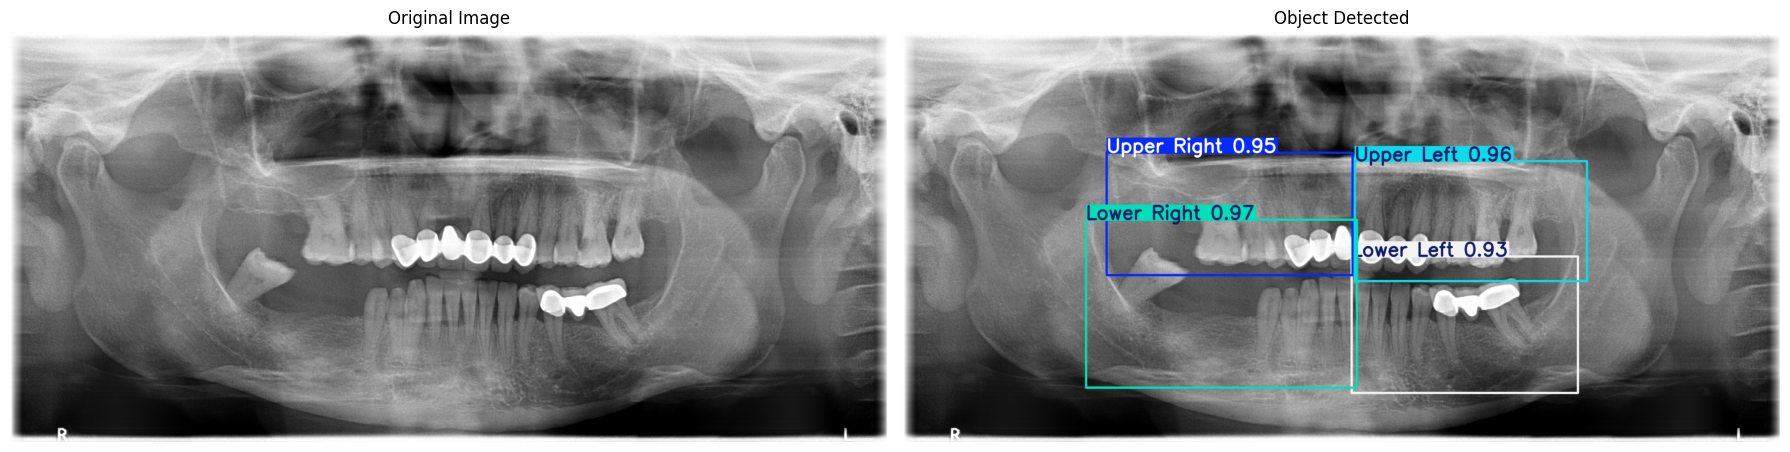

In [29]:
smart_predict(quadrant_model_detection,data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_83.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 141.8ms
Speed: 3.7ms preprocess, 141.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Lower Right
Coordinates: [556.7308959960938, 596.399169921875, 1391.0010986328125, 1085.34814453125]
Confidence: %97.0
Class Name: Upper Left
Coordinates: [1394.5377197265625, 372.0187072753906, 2100.62841796875, 763.7759399414062]
Confidence: %96.0
Class Name: Upper Right
Coordinates: [621.6346435546875, 345.4844055175781, 1395.0511474609375, 769.837646484375]
Confidence: %95.0
Class Name: Lower Left
Coordinates: [1381.8968505859375, 611.2224731445312, 2159.40966796875, 1097.2579345703125]
Confidence: %93.0


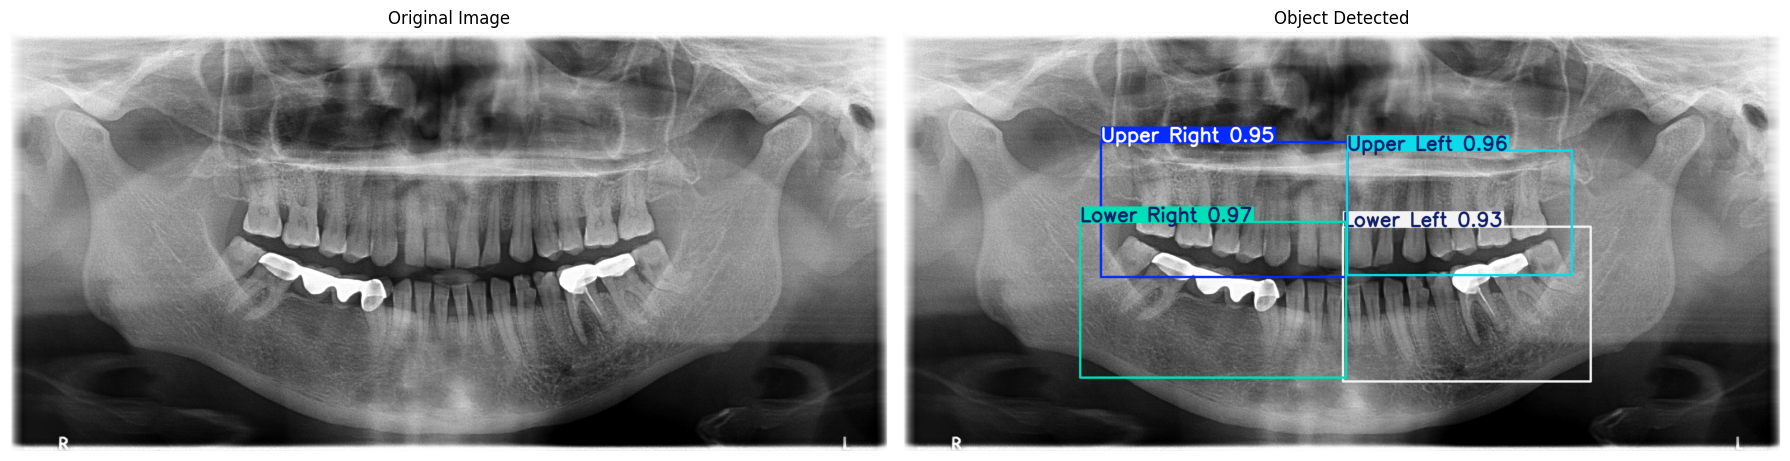

In [32]:
smart_predict(quadrant_model_detection,data_yaml['test'],save_output=True,save_dir=os.path.join(s1_data_output,'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_508.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 105.2ms
Speed: 4.1ms preprocess, 105.2ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Lower Right
Coordinates: [586.8016967773438, 630.9069213867188, 1427.9130859375, 1120.492431640625]
Confidence: %96.0
Class Name: Upper Left
Coordinates: [1433.1993408203125, 306.9171447753906, 2199.778076171875, 744.47607421875]
Confidence: %96.0
Class Name: Upper Right
Coordinates: [660.738525390625, 323.6962585449219, 1438.4530029296875, 739.1800537109375]
Confidence: %96.0
Class Name: Lower Left
Coordinates: [1409.5020751953125, 655.8528442382812, 2283.02197265625, 1141.3868408203125]
Confidence: %93.0


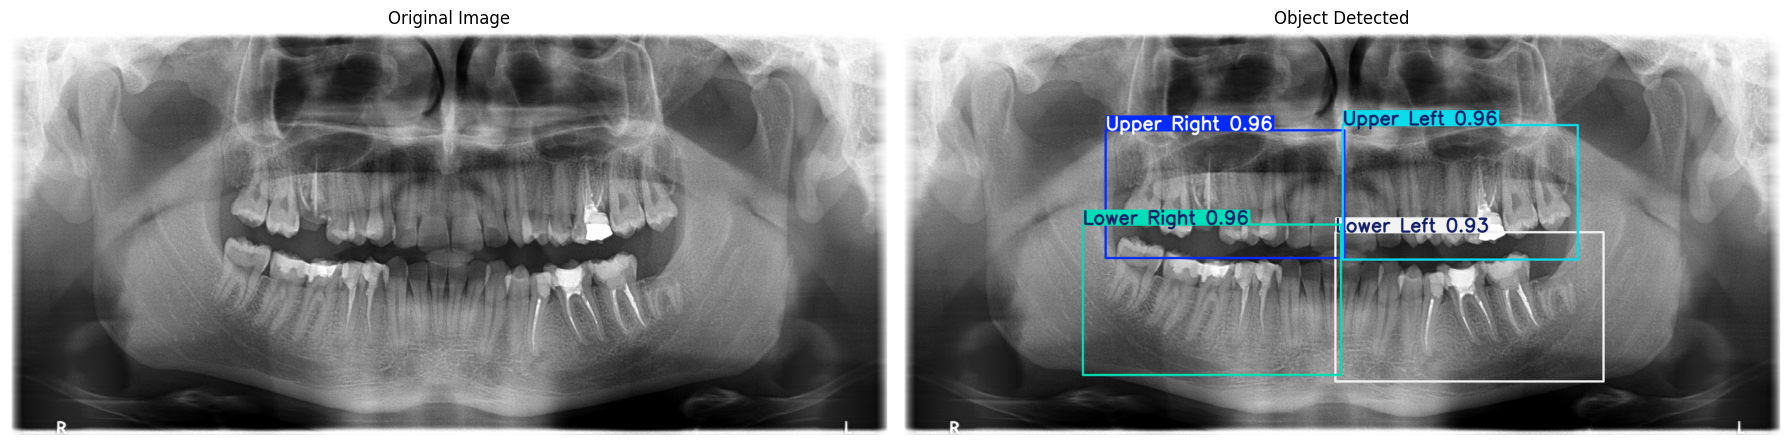

In [30]:
smart_predict(quadrant_model_detection,data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(s1_data_output,'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_512.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 75.2ms
Speed: 7.3ms preprocess, 75.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [582.27734375, 248.68914794921875, 1371.7080078125, 676.1416625976562]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [515.4501342773438, 559.4495849609375, 1348.3294677734375, 1087.950439453125]
Confidence: %98.0
Class Name: Upper Left
Coordinates: [1356.430419921875, 175.21043395996094, 2185.748779296875, 668.7935180664062]
Confidence: %97.0
Class Name: Lower Left
Coordinates: [1330.3450927734375, 538.5769653320312, 2163.968017578125, 1084.993408203125]
Confidence: %97.0


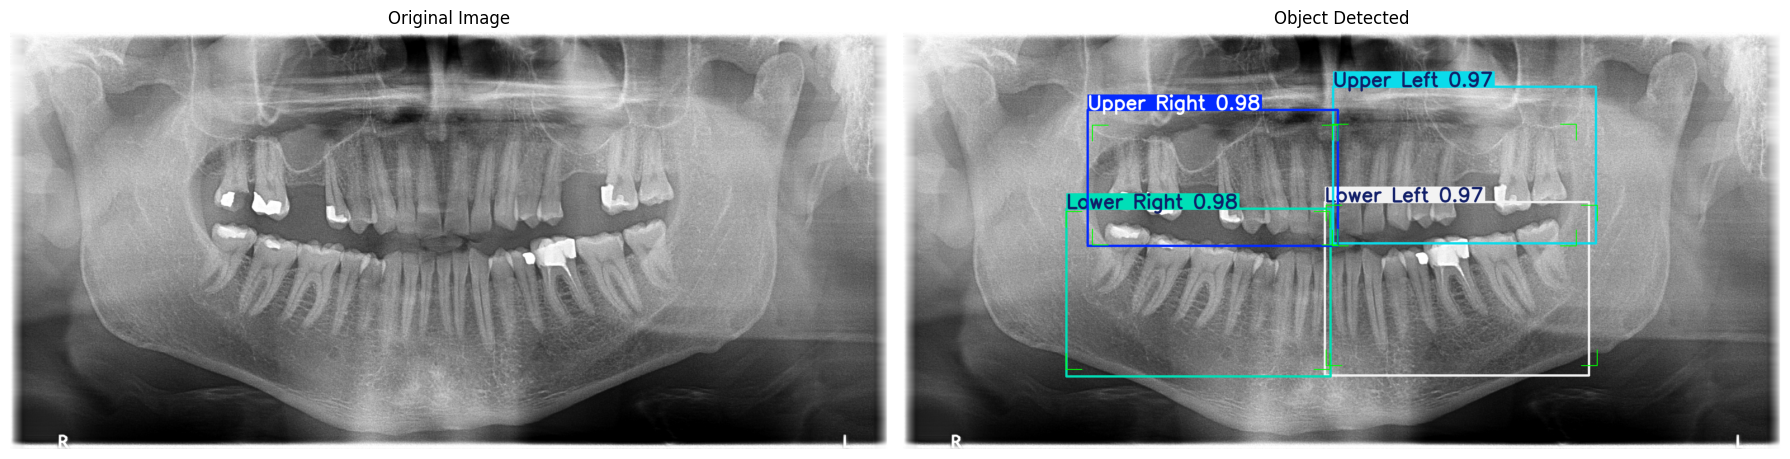

In [9]:
smart_predict(quadrant_model_detection,data_yaml['test'],show_true_boxes=True)


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_76.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 99.4ms
Speed: 23.5ms preprocess, 99.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Left
Coordinates: [1370.99365234375, 400.5506286621094, 2110.138916015625, 779.8068237304688]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [648.6251220703125, 726.8545532226562, 1373.188720703125, 1155.3262939453125]
Confidence: %98.0
Class Name: Upper Right
Coordinates: [623.5604248046875, 415.92291259765625, 1383.498046875, 786.021728515625]
Confidence: %98.0
Class Name: Lower Left
Coordinates: [1358.287353515625, 680.3751831054688, 2192.576416015625, 1117.9698486328125]
Confidence: %97.0


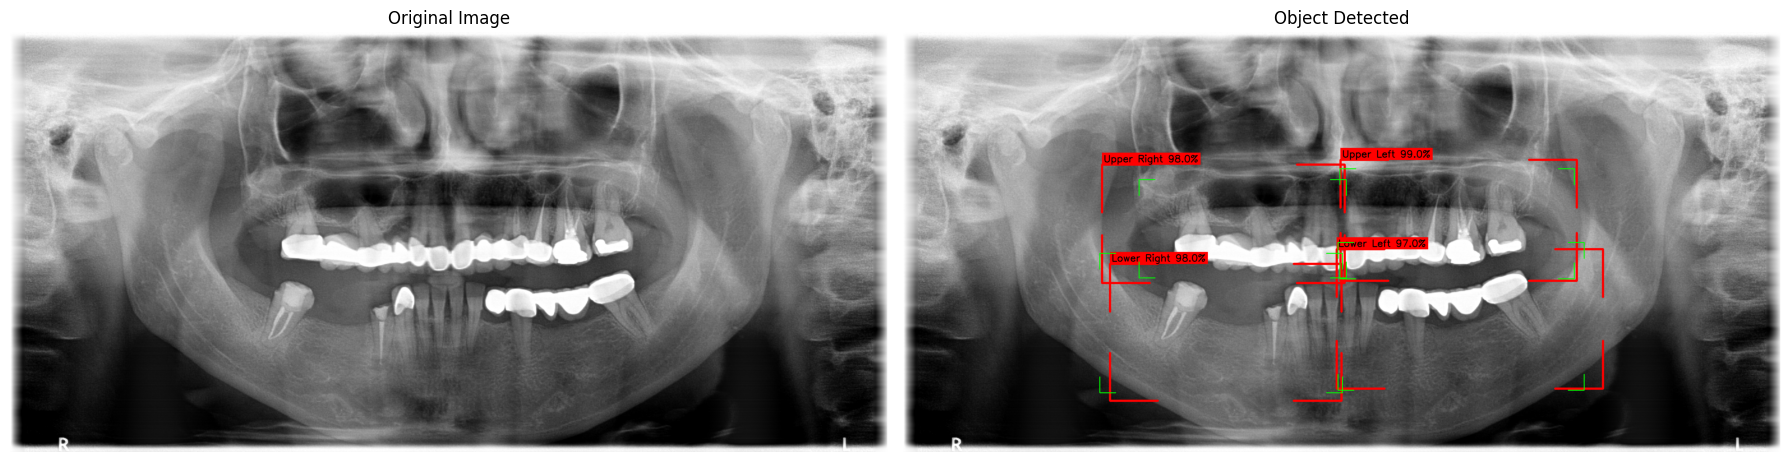

In [10]:
smart_predict(quadrant_model_detection,data_yaml['test'],show_true_boxes=True,apply_custom_draw_box=True)

In [33]:
generate_report(s1_data_output, s1_data_output+'YOLO Training Report (Stage 1).pdf',title='YOLO Training Report (Stage 1)')

Report saved to: ..\Runs\Stage 1\\YOLO Training Report (Stage 1).pdf
